# Machine Learning Task 1 - Restaurant Rating Prediction

This project predicts the `Aggregate rating` of restaurants using restaurant-related features and a Random Forest Regressor.

## Importing Important Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Importing The Dataset

In [2]:
# Keep Dataset .csv in the same folder as this notebook.
# If it is not found there, the code will also check the Downloads folder.
csv_path = Path("Dataset .csv")

if not csv_path.exists():
    csv_path = Path.home() / "Downloads" / "Dataset .csv"

if not csv_path.exists():
    raise FileNotFoundError("Dataset .csv not found. Keep it in the same folder as this notebook.")

dataset = pd.read_csv(csv_path)

print("Dataset loaded from:", csv_path)
dataset

Dataset loaded from: C:\Users\ajay2\Downloads\Dataset .csv


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,208,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Karak�_y,"Karak�_y, ��stanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


## Basic Information About The Dataset

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [ ]:
dataset.head(15)

In [ ]:
print("Dataset shape:", dataset.shape)
print("\nColumns:")
print(dataset.columns)

## Checking Missing Values

In [ ]:
missing_values = dataset.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

## Handling Missing Values

Only `Cuisines` has missing values in this dataset. We fill it using the mode, which is the most frequent cuisine value.

In [ ]:
dataset["Cuisines"] = dataset["Cuisines"].fillna(dataset["Cuisines"].mode()[0])

missing_values = dataset.isnull().sum()
missing_values = missing_values[missing_values > 0]
print("Missing values after cleaning:")
print(missing_values)

## Selecting Useful Features

We remove columns that should not be used for fair prediction:

- `Aggregate rating` is the target variable.
- `Rating color` and `Rating text` are directly created from rating, so using them would cause data leakage.
- `Restaurant ID`, `Restaurant Name`, `Address`, `Locality`, and `Locality Verbose` are mostly identifiers/text details and create too many unnecessary columns.

In [4]:
target = "Aggregate rating"

columns_to_drop = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality",
    "Locality Verbose",
    "Rating color",
    "Rating text",
    target
]

X = dataset.drop(columns=columns_to_drop)
y = dataset[target]

print("Feature columns before encoding:")
print(X.columns)
print("\nTarget variable:", target)

Feature columns before encoding:
Index(['Country Code', 'City', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Votes'],
      dtype='object')

Target variable: Aggregate rating


## One Hot Encoding

Categorical text columns are converted into numerical columns using one hot encoding.

In [5]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after one hot encoding:", X.shape)
X.head()

Shape after one hot encoding: (9551, 1984)


,Country Code,Longitude,Latitude,Average Cost for two,Price range,Votes,City_Agra,City_Ahmedabad,City_Albany,City_Allahabad,...,Currency_Indonesian Rupiah(IDR),Currency_NewZealand($),Currency_Pounds(��),Currency_Qatari Rial(QR),Currency_Rand(R),Currency_Sri Lankan Rupee(LKR),Currency_Turkish Lira(TL),Has Table booking_Yes,Has Online delivery_Yes,Is delivering now_Yes
0,162,121.027535,14.565443,1100,3,314,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,162,121.014101,14.553708,1200,3,591,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,162,121.056831,14.581404,4000,4,270,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,162,121.056475,14.585318,1500,4,365,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,162,121.057508,14.584450,1500,4,229,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Splitting The Data Into Training And Testing Sets

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (7163, 1984)
Testing data shape: (2388, 1984)


## Training Random Forest Regressor

Random Forest Regressor is used because the target value, `Aggregate rating`, is numerical. This makes it a regression problem.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    max_depth=15,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

Mean Absolute Error: 0.20109375389117798
Mean Squared Error: 0.09707011834160173
R-squared Score: 0.9570125159848278


## Model Evaluation Meaning

- Mean Absolute Error tells the average rating difference between actual and predicted values.
- Mean Squared Error tells how large the squared prediction errors are.
- R-squared tells how much variation in restaurant rating is explained by the model.

After removing leakage columns, the score may be lower than before, but it is more correct and fair.

## Feature Importance

Feature importance shows which features helped the model most while predicting restaurant ratings.

In [8]:
feature_importances = model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(15)

,Feature,Importance
5,Votes,0.962686
1,Longitude,0.008979
2,Latitude,0.006933
3,Average Cost for two,0.003497
0,Country Code,0.003039
1973,Currency_Indian Rupees(Rs.),0.000801
1474,"Cuisines_North Indian, Chinese",0.000571
1982,Has Online delivery_Yes,0.000482
203,"Cuisines_American, Fast Food, Salad, Healthy Food",0.000425
4,Price range,0.000376


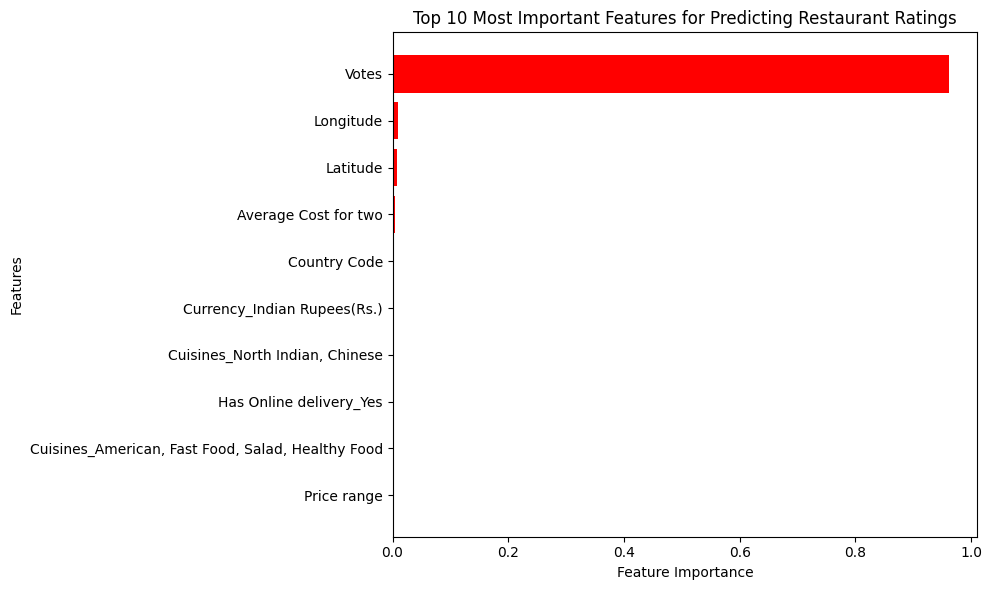

In [9]:
N = 10
top_features = importance_df.head(N)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"], color="red")
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title(f"Top {N} Most Important Features for Predicting Restaurant Ratings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

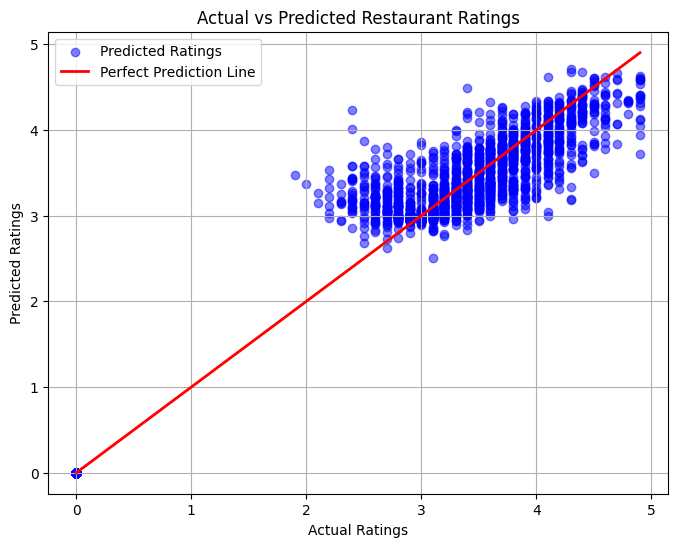

In [10]:
# Actual vs Predicted Ratings Graph

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, color="blue", alpha=0.5, label="Predicted Ratings")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2,
    label="Perfect Prediction Line"
)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Restaurant Ratings")
plt.legend()
plt.grid(True)
plt.show()
